# Insurance Cost Analysis


## Objectives 

 - Load the data as a `pandas` dataframe
 - Clean the data, taking care of the blank entries
 - Run exploratory data analysis (EDA) and identify the attributes that most affect the `charges`
 - Develop single variable and multi variable Linear Regression models for predicting the `charges`
 - Use Ridge regression to refine the performance of Linear regression models. 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, train_test_split

filepath = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-Coursera/medical_insurance_dataset.csv'


Print the first 10 rows of the dataframe to confirm successful loading.


In [2]:
df=pd.read_csv(filepath,header=None)
print(df.head(10))

    0  1       2  3  4  5            6
0  19  1  27.900  0  1  3  16884.92400
1  18  2  33.770  1  0  4   1725.55230
2  28  2  33.000  3  0  4   4449.46200
3  33  2  22.705  0  0  1  21984.47061
4  32  2  28.880  0  0  1   3866.85520
5  31  1  25.740  0  ?  4   3756.62160
6  46  1  33.440  1  0  4   8240.58960
7  37  1  27.740  3  0  1   7281.50560
8  37  2  29.830  2  0  2   6406.41070
9  60  1  25.840  0  0  1  28923.13692


Add the headers to the dataframe.

In [3]:
headers = ["age", "gender", "bmi", "no_of_children", "smoker", "region", "charges"]
df.columns = headers
print(df.head(10))

  age  gender     bmi  no_of_children smoker  region      charges
0  19       1  27.900               0      1       3  16884.92400
1  18       2  33.770               1      0       4   1725.55230
2  28       2  33.000               3      0       4   4449.46200
3  33       2  22.705               0      0       1  21984.47061
4  32       2  28.880               0      0       1   3866.85520
5  31       1  25.740               0      ?       4   3756.62160
6  46       1  33.440               1      0       4   8240.58960
7  37       1  27.740               3      0       1   7281.50560
8  37       2  29.830               2      0       2   6406.41070
9  60       1  25.840               0      0       1  28923.13692


Now, replace the '?' entries with 'NaN' values

In [4]:
df.replace('?',np.nan,inplace=True)
print(df.head(10))

  age  gender     bmi  no_of_children smoker  region      charges
0  19       1  27.900               0      1       3  16884.92400
1  18       2  33.770               1      0       4   1725.55230
2  28       2  33.000               3      0       4   4449.46200
3  33       2  22.705               0      0       1  21984.47061
4  32       2  28.880               0      0       1   3866.85520
5  31       1  25.740               0    NaN       4   3756.62160
6  46       1  33.440               1      0       4   8240.58960
7  37       1  27.740               3      0       1   7281.50560
8  37       2  29.830               2      0       2   6406.41070
9  60       1  25.840               0      0       1  28923.13692


# Data Wrangling
Use dataframe.info() to identify the columns that have some 'Null' (or NaN) information.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             2768 non-null   object 
 1   gender          2772 non-null   int64  
 2   bmi             2772 non-null   float64
 3   no_of_children  2772 non-null   int64  
 4   smoker          2765 non-null   object 
 5   region          2772 non-null   int64  
 6   charges         2772 non-null   float64
dtypes: float64(2), int64(3), object(2)
memory usage: 151.7+ KB


Handle missing data:

- For continuous attributes (e.g., age), replace missing values with the mean.
- For categorical attributes (e.g., smoker), replace missing values with the most frequent value.
- Update the data types of the respective columns.
- Verify the update using df.info().

In [6]:
df['age'] = pd.to_numeric(df['age'], errors='coerce')
df['age'] = df['age'].fillna(df['age'].mean())
df['smoker'] = df['smoker'].fillna(df['smoker'].mode()[0])
df['age'] = df['age'].astype(float)
df['smoker'] = df['smoker'].astype('category')

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   age             2772 non-null   float64 
 1   gender          2772 non-null   int64   
 2   bmi             2772 non-null   float64 
 3   no_of_children  2772 non-null   int64   
 4   smoker          2772 non-null   category
 5   region          2772 non-null   int64   
 6   charges         2772 non-null   float64 
dtypes: category(1), float64(3), int64(3)
memory usage: 132.9 KB


the `charges` column has values which are more than 2 decimal places long. Update the `charges` column such that all values are rounded to nearest 2 decimal places. Verify conversion by printing the first 5 values of the updated dataframe.


In [7]:
df[["charges"]] = np.round(df[["charges"]],2)
print(df.head())


    age  gender     bmi  no_of_children smoker  region   charges
0  19.0       1  27.900               0      1       3  16884.92
1  18.0       2  33.770               1      0       4   1725.55
2  28.0       2  33.000               3      0       4   4449.46
3  33.0       2  22.705               0      0       1  21984.47
4  32.0       2  28.880               0      0       1   3866.86


# Exploratory Data Analysis (EDA)

Implement the regression plot for `charges` with respect to `bmi`. 

(0.0, 66902.85800000001)

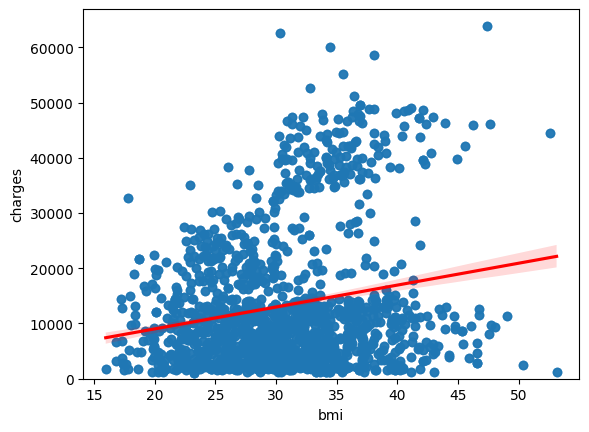

In [8]:
sns.regplot(x="bmi", y="charges", data=df, line_kws={"color": "red"})
plt.ylim(0,)

<Axes: xlabel='smoker', ylabel='charges'>

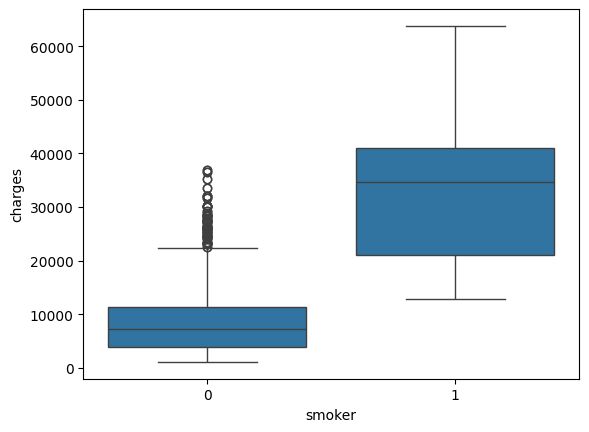

In [9]:
sns.boxplot(x="smoker", y="charges", data=df)

Print the correlation matrix for the dataset.

In [10]:
df.replace('?', np.nan, inplace=True)
df.dropna(inplace=True)
print(df.corr())

                     age    gender       bmi  no_of_children    smoker  \
age             1.000000 -0.026041  0.113045        0.037585 -0.023285   
gender         -0.026041  1.000000  0.042924        0.016020  0.082326   
bmi             0.113045  0.042924  1.000000       -0.001492  0.011489   
no_of_children  0.037585  0.016020 -0.001492        1.000000  0.006362   
smoker         -0.023285  0.082326  0.011489        0.006362  1.000000   
region         -0.007175  0.022213  0.271119       -0.025717  0.054077   
charges         0.298622  0.062837  0.199846        0.066442  0.788783   

                  region   charges  
age            -0.007175  0.298622  
gender          0.022213  0.062837  
bmi             0.271119  0.199846  
no_of_children -0.025717  0.066442  
smoker          0.054077  0.788783  
region          1.000000  0.054058  
charges         0.054058  1.000000  


# Model Development

Fit a linear regression model that may be used to predict the `charges` value, just by using the `smoker` attribute of the dataset. Print the $ R^2 $ score of this model.

In [11]:
df['smoker'] = pd.to_numeric(df['smoker'], errors='coerce')
X = df[['smoker']].astype(float) 
Y = df['charges'].astype(float) 

lm = LinearRegression()
lm.fit(X, Y)
print("R² Score:", lm.score(X, Y))


R² Score: 0.6221791733924185


Fit a linear regression model that may be used to predict the `charges` value, just by using all other attributes of the dataset. Print the $ R^2 $ score of this model. You should see an improvement in the performance.


In [12]:
Z = df[["age", "gender", "bmi", "no_of_children", "smoker", "region"]]
lm.fit(Z,Y)
print("R^2 score:",lm.score(Z,Y))

R^2 score: 0.7504063772187107


Create a training pipeline that uses StandardScaler(), PolynomialFeatures() and LinearRegression() to create a model that can predict the charges value using all the other attributes of the dataset. There should be even further improvement in the performance.

In [13]:
Input = [('scale',StandardScaler()),('polynomial',PolynomialFeatures()),('model',LinearRegression())]
pipe = Pipeline(Input)
Z = Z.astype('float')
pipe.fit(Z,Y)
ypipe = pipe.predict(Z)
print(r2_score(Y,ypipe))

0.8452558518297514


# Model Refinement

Split the data into training and testing subsets, assuming that 20% of the data will be reserved for testing.


In [14]:
x_train, x_test, y_train, y_test = train_test_split(Z, Y, test_size=0.2, random_state = 1)

Initialize a Ridge regressor that used hyperparameter $ \alpha = 0.1 $. Fit the model using training data data subset. Print the $ R^2 $ score for the testing data.


In [15]:
ridge = Ridge(alpha=0.1)
ridge.fit(x_train,y_train)
yridge = ridge.predict(x_test)
print(r2_score(y_test,yridge))

0.6760802462837336


Apply polynomial transformation to the training parameters with degree=2. Use this transformed feature set to fit the same regression model, as above, using the training subset. Print the $ R^2 $ score for the testing subset.

In [16]:
pr = PolynomialFeatures(degree = 2)
x_train_pr =pr.fit_transform(x_train)
x_test_pr = pr.transform(x_test)
ridge.fit(x_train_pr,y_train)
yridge = ridge.predict(x_test_pr)
print(r2_score(y_test,yridge))


0.7835630578755346


In [17]:
import numpy as np 
import pandas as pd
df_can = pd.read_excel(
    'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DV0101EN-SkillsNetwork/Data%20Files/Canada.xlsx',
    sheet_name='Canada by Citizenship',
    skiprows=range(20),
    skipfooter=2)

print('Data read into a pandas dataframe!')
df_can.head()

Data read into a pandas dataframe!


,Type,Coverage,OdName,AREA,AreaName,REG,RegName,DEV,DevName,1980,...,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013
0,Immigrants,Foreigners,Afghanistan,935,Asia,5501,Southern Asia,902,Developing regions,16,...,2978,3436,3009,2652,2111,1746,1758,2203,2635,2004
1,Immigrants,Foreigners,Albania,908,Europe,925,Southern Europe,901,Developed regions,1,...,1450,1223,856,702,560,716,561,539,620,603
2,Immigrants,Foreigners,Algeria,903,Africa,912,Northern Africa,902,Developing regions,80,...,3616,3626,4807,3623,4005,5393,4752,4325,3774,4331
3,Immigrants,Foreigners,American Samoa,909,Oceania,957,Polynesia,902,Developing regions,0,...,0,0,1,0,0,0,0,0,0,0
4,Immigrants,Foreigners,Andorra,908,Europe,925,Southern Europe,901,Developed regions,0,...,0,0,1,1,0,0,0,0,1,1


In [18]:
df_can.tail()

,Type,Coverage,OdName,AREA,AreaName,REG,RegName,DEV,DevName,1980,...,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013
190,Immigrants,Foreigners,Viet Nam,935,Asia,920,South-Eastern Asia,902,Developing regions,1191,...,1816,1852,3153,2574,1784,2171,1942,1723,1731,2112
191,Immigrants,Foreigners,Western Sahara,903,Africa,912,Northern Africa,902,Developing regions,0,...,0,0,1,0,0,0,0,0,0,0
192,Immigrants,Foreigners,Yemen,935,Asia,922,Western Asia,902,Developing regions,1,...,124,161,140,122,133,128,211,160,174,217
193,Immigrants,Foreigners,Zambia,903,Africa,910,Eastern Africa,902,Developing regions,11,...,56,91,77,71,64,60,102,69,46,59
194,Immigrants,Foreigners,Zimbabwe,903,Africa,910,Eastern Africa,902,Developing regions,72,...,1450,615,454,663,611,508,494,434,437,407


In [19]:
df_can.info(verbose=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Columns: 43 entries, Type to 2013
dtypes: int64(37), object(6)
memory usage: 65.6+ KB


In [20]:
print(type(df_can.columns))
print(type(df_can.index))

<class 'pandas.core.indexes.base.Index'>
<class 'pandas.core.indexes.range.RangeIndex'>


In [21]:
print(type(df_can.columns.tolist()))
print(type(df_can.index.tolist()))

<class 'list'>
<class 'list'>


In [22]:
df_can.drop(['AREA','REG','DEV','Type','Coverage'], axis=1, inplace=True)
df_can.head(2)

,OdName,AreaName,RegName,DevName,1980,1981,1982,1983,1984,1985,...,2004,2005,2006,2007,2008,2009,2010,2011,2012,2013
0,Afghanistan,Asia,Southern Asia,Developing regions,16,39,39,47,71,340,...,2978,3436,3009,2652,2111,1746,1758,2203,2635,2004
1,Albania,Europe,Southern Europe,Developed regions,1,0,0,0,0,0,...,1450,1223,856,702,560,716,561,539,620,603


In [23]:
df_can.rename(columns={'OdName':'Country', 'AreaName':'Continent', 'RegName':'Region'}, inplace=True)
df_can.columns

Index([  'Country', 'Continent',    'Region',   'DevName',        1980,
              1981,        1982,        1983,        1984,        1985,
              1986,        1987,        1988,        1989,        1990,
              1991,        1992,        1993,        1994,        1995,
              1996,        1997,        1998,        1999,        2000,
              2001,        2002,        2003,        2004,        2005,
              2006,        2007,        2008,        2009,        2010,
              2011,        2012,        2013],
      dtype='object')

In [24]:
df_can.columns = df_can.columns.astype(str).str.strip()
years = list(map(str, range(1980, 2014)))
df_can['Total'] = df_can[years].sum(axis=1)
print(df_can['Total'])

0      58639
1      15699
2      69439
3          6
4         15
       ...  
190    97146
191        2
192     2985
193     1677
194     8598
Name: Total, Length: 195, dtype: int64


In [25]:
df_can.isnull().sum()

Country      0
Continent    0
Region       0
DevName      0
1980         0
1981         0
1982         0
1983         0
1984         0
1985         0
1986         0
1987         0
1988         0
1989         0
1990         0
1991         0
1992         0
1993         0
1994         0
1995         0
1996         0
1997         0
1998         0
1999         0
2000         0
2001         0
2002         0
2003         0
2004         0
2005         0
2006         0
2007         0
2008         0
2009         0
2010         0
2011         0
2012         0
2013         0
Total        0
dtype: int64

In [26]:
df.describe()

,age,gender,bmi,no_of_children,smoker,region,charges
count,2772.000000,2772.000000,2772.000000,2772.000000,2772.000000,2772.000000,2772.000000
mean,39.109827,1.507215,30.701349,1.101732,0.203463,2.559885,13261.369957
std,14.081459,0.500038,6.129449,1.214806,0.402647,1.130761,12151.768970
min,18.000000,1.000000,15.960000,0.000000,0.000000,1.000000,1121.870000
25%,26.000000,1.000000,26.220000,0.000000,0.000000,2.000000,4687.800000
50%,39.000000,2.000000,30.447500,1.000000,0.000000,3.000000,9333.015000
75%,51.000000,2.000000,34.770000,2.000000,0.000000,4.000000,16577.780000
max,64.000000,2.000000,53.130000,5.000000,1.000000,4.000000,63770.430000


In [27]:
 df_can[['Country', '1980', '1981', '1982', '1983', '1984', '1985']] 

,Country,1980,1981,1982,1983,1984,1985
0,Afghanistan,16,39,39,47,71,340
1,Albania,1,0,0,0,0,0
2,Algeria,80,67,71,69,63,44
3,American Samoa,0,1,0,0,0,0
4,Andorra,0,0,0,0,0,0
...,...,...,...,...,...,...,...
190,Viet Nam,1191,1829,2162,3404,7583,5907
191,Western Sahara,0,0,0,0,0,0
192,Yemen,1,2,1,6,0,18
193,Zambia,11,17,11,7,16,9


In [28]:
df_can.columns

Index(['Country', 'Continent', 'Region', 'DevName', '1980', '1981', '1982',
       '1983', '1984', '1985', '1986', '1987', '1988', '1989', '1990', '1991',
       '1992', '1993', '1994', '1995', '1996', '1997', '1998', '1999', '2000',
       '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009',
       '2010', '2011', '2012', '2013', 'Total'],
      dtype='object')

In [29]:
df_can.set_index('Continent', inplace=True)
df_can.head(2)

,Country,Region,DevName,1980,1981,1982,1983,1984,1985,1986,...,2005,2006,2007,2008,2009,2010,2011,2012,2013,Total
Continent,,,,,,,,,,,,,,,,,,,,,
Asia,Afghanistan,Southern Asia,Developing regions,16,39,39,47,71,340,496,...,3436,3009,2652,2111,1746,1758,2203,2635,2004,58639
Europe,Albania,Southern Europe,Developed regions,1,0,0,0,0,0,1,...,1223,856,702,560,716,561,539,620,603,15699


In [30]:
df_can.loc['Asia']


,Country,Region,DevName,1980,1981,1982,1983,1984,1985,1986,...,2005,2006,2007,2008,2009,2010,2011,2012,2013,Total
Continent,,,,,,,,,,,,,,,,,,,,,
Asia,Afghanistan,Southern Asia,Developing regions,16,39,39,47,71,340,496,...,3436,3009,2652,2111,1746,1758,2203,2635,2004,58639
Asia,Armenia,Western Asia,Developing regions,0,0,0,0,0,0,0,...,224,218,198,205,267,252,236,258,207,3310
Asia,Azerbaijan,Western Asia,Developing regions,0,0,0,0,0,0,0,...,359,236,203,125,165,209,138,161,57,2649
Asia,Bahrain,Western Asia,Developing regions,0,2,1,1,1,3,0,...,12,12,22,9,35,28,21,39,32,475
Asia,Bangladesh,Southern Asia,Developing regions,83,84,86,81,98,92,486,...,4171,4014,2897,2939,2104,4721,2694,2640,3789,65568
Asia,Bhutan,Southern Asia,Developing regions,0,0,0,0,1,0,0,...,5,10,7,36,865,1464,1879,1075,487,5876
Asia,Brunei Darussalam,South-Eastern Asia,Developing regions,79,6,8,2,2,4,12,...,4,5,11,10,5,12,6,3,6,600
Asia,Cambodia,South-Eastern Asia,Developing regions,12,19,26,33,10,7,8,...,370,529,460,354,203,200,196,233,288,6538
Asia,China,Eastern Asia,Developing regions,5123,6682,3308,1863,1527,1816,1960,...,42584,33518,27642,30037,29622,30391,28502,33024,34129,659962


In [31]:
df_can.iloc[87]

Country                Japan
Region          Eastern Asia
DevName    Developed regions
1980                     701
1981                     756
1982                     598
1983                     309
1984                     246
1985                     198
1986                     248
1987                     422
1988                     324
1989                     494
1990                     379
1991                     506
1992                     605
1993                     907
1994                     956
1995                     826
1996                     994
1997                     924
1998                     897
1999                    1083
2000                    1010
2001                    1092
2002                     806
2003                     817
2004                     973
2005                    1067
2006                    1212
2007                    1250
2008                    1284
2009                    1194
2010                    1168
2011          

In [32]:
df_can.iloc[87, 36]

np.int64(982)

In [33]:
df_can.loc['Asia', ['1980', '1981', '1982', '1983', '1984', '1984']]

,1980,1981,1982,1983,1984,1984
Continent,,,,,,
Asia,16,39,39,47,71,71
Asia,0,0,0,0,0,0
Asia,0,0,0,0,0,0
Asia,0,2,1,1,1,1
Asia,83,84,86,81,98,98
Asia,0,0,0,0,1,1
Asia,79,6,8,2,2,2
Asia,12,19,26,33,10,10
Asia,5123,6682,3308,1863,1527,1527


In [34]:
%matplotlib inline 

import matplotlib as mpl
import matplotlib.pyplot as plt



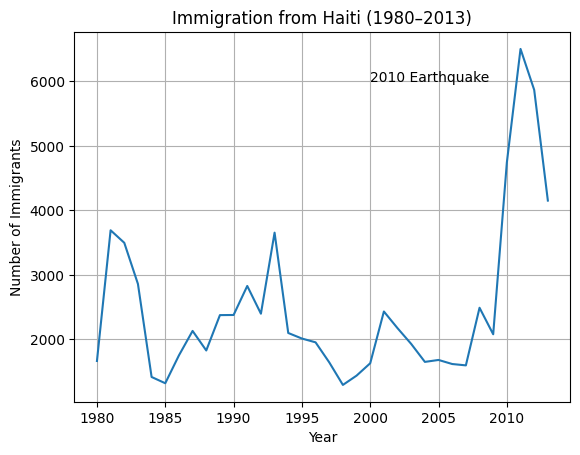

In [35]:
years = list(map(str, range(1980, 2014)))
#creating data series
haiti = df_can.loc['Asia', years] # passing in years 1980 - 2013 to exclude the 'total' column
haiti.head()

# Make sure 'Country' is the index
df_can.set_index('Country', inplace=True)

# Get Haiti's data
haiti = df_can.loc['Haiti', years]

# Convert index to integer
haiti.index = haiti.index.map(int)

# Plot
haiti.plot(kind='line')
plt.title('Immigration from Haiti (1980–2013)')
plt.xlabel('Year')
plt.ylabel('Number of Immigrants')
plt.grid(True)
plt.text(2000, 6000, '2010 Earthquake') 
plt.show()
